## Environment guidance (read first)

This notebook runs cleanest in **Google Colab** or in a **fresh conda environment**. Reusing a cluttered course environment is the single most common cause of trouble here, because a mix of packages installed over the term can leave you with a mismatched numpy/scipy pair that breaks imports deep inside a later tool.

If you are on your own machine, make a fresh environment first:

```
conda create -n arch-lab python=3.11 -y
conda activate arch-lab
pip install torch torchvision grad-cam rdkit umap-learn networkx pandas scikit-learn matplotlib tqdm datasets
```

If you ever see a **numpy** or **scipy** error (for example something about `numpy._no_nep50_warning`, or a version mismatch), the fix is always the same: run the repair cell below, then **Kernel -> Restart**, then run the notebook top to bottom.

# Day 3 Lab: The Architectures Toolbox

Yesterday you turned words into vectors. Today you do the same for **images, sequences, and graphs**, using the architecture that matches each kind of data. The recurring move is simple: take a model, use it to produce an embedding, then explore or build with that embedding.

By the end of this lab you will be able to:

1. Turn images into vectors with a **pretrained CNN**, and see what it looks at with Grad-CAM
2. Do **transfer learning** two ways, feature extraction and fine-tuning, on your own labels
3. Turn sequences into vectors with an **LSTM** encoder, and fine-tune it
4. Turn molecules into vectors with **RDKit**, and analyze graphs with **NetworkX**
5. **Explore** any embedding space (nearest neighbors, clustering, a 2D map)
6. **Export** your embeddings and build a small app on your own machine

**Runs anywhere.** It picks a GPU on Colab (CUDA), the Apple GPU on a Mac (MPS), or the CPU, whichever you have. Every long loop shows a `tqdm` bar so you can see how long things will take, and the data is sampled small so cells finish quickly even on an older laptop.

## Section 0: Setup

Run this first. The very first cell installs and, if needed, **repairs** the environment: it forces a consistent numpy/scipy pair before anything imports them, then installs the rest of the extras. If that cell reports it upgraded numpy or scipy, do **Kernel -> Restart** before continuing, then run top to bottom.

After that we set an environment variable **before importing torch** so any operation not yet supported on the Apple GPU quietly falls back to the CPU, and we pick the best available device.

In [1]:
# run this before any numpy/torch/scipy import. it repairs mismatched envs.
# force a consistent numpy+scipy pair first (this is what fixes broken course envs),
# then install the rest. %pip targets the kernel actually running this notebook.
%pip install -q -U --no-cache-dir numpy scipy
%pip install -q grad-cam rdkit umap-learn networkx pandas scikit-learn matplotlib tqdm datasets
# torch and torchvision are assumed present (Colab ships them; the fresh-env recipe installs them)

print("setup done. if this cell just upgraded numpy or scipy, do Kernel -> Restart before continuing.")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.62.1 requires numpy<2.4,>=1.22, but you have numpy 2.5.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
setup done. if this cell just upgraded numpy or scipy, do Kernel -> Restart before continuing.


### Health check

A quick import of the core libraries so any version mismatch shows up here, at the top, rather than deep inside a later tool. If it fails, run the repair cell above, then Kernel -> Restart, then rerun from the top.

In [2]:
import os
# must be set before torch is imported; lets unsupported ops fall back to CPU on Mac
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

def pickDevice():
    "the apple gpu (mps) if present, else a cuda gpu, else the cpu"
    import torch
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

try:
    import numpy, scipy, sklearn, torch
    from scipy.ndimage import zoom          # this is the import path that trips a broken numpy/scipy
    device = pickDevice()
    print("numpy", numpy.__version__)
    print("scipy", scipy.__version__)
    print("sklearn", sklearn.__version__)
    print("torch", torch.__version__)
    print("device:", device)
except Exception as e:
    device = None
    print("import failed:", type(e).__name__, e)
    print("this usually means a mismatched numpy/scipy pair.")
    print("fix: run the repair cell above, then Kernel -> Restart, then rerun from the top.")

numpy 2.3.5
scipy 1.18.0
sklearn 1.7.2
torch 2.12.1
device: mps


### Sample sizes

These control how much data each section uses. They are kept small so everything runs in a minute or two on a laptop. Turn them up if you have a GPU and want sharper results.

In [3]:
n_images = 150        # images to embed with the CNN
n_per_class = 60      # training images per class for transfer learning
n_test_class = 40     # test images per class
lstm_steps = 250      # training steps for the character LSTM
n_molecules = 400     # molecules to use from the solubility dataset

### tqdm: watch your runtimes

`tqdm` wraps any loop and shows a live bar with an estimated time remaining. Use `from tqdm.auto import tqdm` so it renders nicely in the notebook.

In [4]:
import time
from tqdm.auto import tqdm

total = 0
for i in tqdm(range(30), desc="warming up"):
    total += i
    time.sleep(0.02)
print("done, total =", total)

warming up:   0%|          | 0/30 [00:00<?, ?it/s]

done, total = 435


---
## Tool 1: Images to vectors with a pretrained CNN

A CNN trained on millions of images has already learned a rich feature hierarchy. We borrow it: run an image through the network and read off the vector just before the final classifier. That vector is a compact summary of the image, an **image2vec**. We use **ResNet18**, which is small and fast.

In [5]:
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.feature_extraction import create_feature_extractor

weights = ResNet18_Weights.IMAGENET1K_V1
preprocess = weights.transforms()                  # the matching resize and normalize steps
cnn = resnet18(weights=weights).eval().to(device)

# the node named "flatten" is the 512-dim vector just before the classifier head
extractor = create_feature_extractor(cnn, return_nodes={"flatten": "feat"})
print("resnet18 feature extractor ready on", device)

resnet18 feature extractor ready on mps


We embed a small batch of images. We **stream** a slice of CIFAR-10 from the Hugging Face hub, so only the images we actually use get downloaded, not the full 160 MB archive. (`datasets` fetches from a fast CDN and stops as soon as we have enough.) You can point this at your own folder of images instead. Extracting in batches is much faster than one image at a time.

In [6]:
import numpy as np
from datasets import load_dataset
from itertools import islice

# cifar-10 label names, in the standard order
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

def cifarStream(split):
    "stream cifar-10 from the huggingface cdn, downloading only the images we use"
    try:
        return load_dataset("uoft-cs/cifar10", split=split, streaming=True)
    except Exception:
        return load_dataset("cifar10", split=split, streaming=True)

# pull just the first n_images off the stream, no full-dataset download
gallery = list(islice(cifarStream("test"), n_images))
img_pils = [ex["img"] for ex in gallery]
img_labels = [classes[ex["label"]] for ex in gallery]

def batchedImageVectors(pils, batch=32):
    "embed a list of PIL images with the CNN, in batches, and return a numpy array"
    vecs = []
    for i in tqdm(range(0, len(pils), batch), desc="image2vec"):
        x = torch.stack([preprocess(p) for p in pils[i:i+batch]]).to(device)
        with torch.no_grad():
            vecs.append(extractor(x)["feat"].float().cpu().numpy())
    return np.concatenate(vecs, axis=0)

img_vectors = batchedImageVectors(img_pils)
print("embedded", img_vectors.shape[0], "images into", img_vectors.shape[1], "dims")

README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

image2vec:   0%|          | 0/5 [00:00<?, ?it/s]

embedded 150 images into 512 dims


## Tool 2: What the CNN looks at (Grad-CAM)

Grad-CAM paints a heatmap over the image showing which pixels most drove the prediction. It needs gradients through a convolution, which is one of the operations that can misbehave on the Apple GPU, so we run this one block on the **CPU**. It is only a single image, so it is quick.

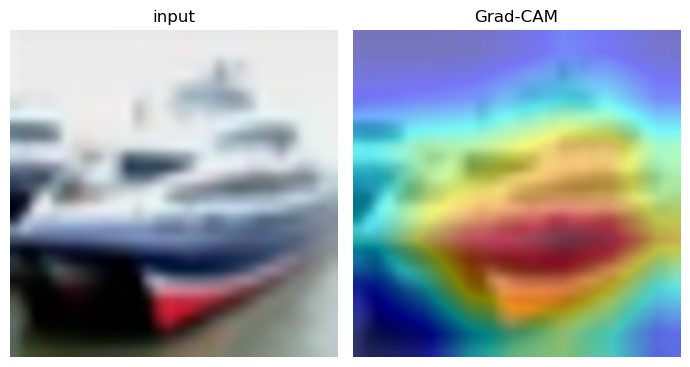

In [10]:
# importing grad-cam pulls in scipy.ndimage, which is where a broken numpy/scipy env shows up.
# a harmless "objc[...] Class ... implemented in both av ... and cv2 ..." message may appear here; ignore it.
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
except Exception as e:
    print("could not import grad-cam:", type(e).__name__, e)
    print("this usually means a mismatched numpy/scipy pair.")
    print("fix: run the repair cell in Section 0, then Kernel -> Restart, then rerun from the top.")
    raise
import matplotlib.pyplot as plt

cam_model = resnet18(weights=weights).eval()        # a fresh copy, kept on the CPU
sample = img_pils[1]
rgb = np.array(sample.resize((224, 224))).astype(np.float32) / 255.0   # float in [0, 1]
input_tensor = preprocess(sample).unsqueeze(0)      # on CPU

with GradCAM(model=cam_model, target_layers=[cam_model.layer4[-1]]) as cam:
    heatmap = cam(input_tensor=input_tensor)[0]     # targets=None uses the top class
overlay = show_cam_on_image(rgb, heatmap, use_rgb=True)

fig, ax = plt.subplots(1, 2, figsize=(7, 4))
ax[0].imshow(rgb); ax[0].set_title("input"); ax[0].axis("off")
ax[1].imshow(overlay); ax[1].set_title("Grad-CAM"); ax[1].axis("off")
plt.tight_layout(); plt.show()

---
## Tool 3: Transfer learning

Transfer learning reuses a model trained on one task for another. It comes in two flavors, and we will try both on a small three-class image problem.

- **Feature extraction.** Freeze the pretrained backbone, treat it as a fixed feature maker, and train only a small new head. Fast, and great on small datasets.
- **Fine-tuning.** Unfreeze some of the backbone as well and keep training with a small learning rate, so the features themselves adapt to your data.

First we build a small labeled set of three CIFAR classes, again by streaming and stopping as soon as we have enough of each class.

In [11]:
from torch.utils.data import DataLoader, TensorDataset

pick = ["cat", "dog", "ship"]
pick_ids = [classes.index(c) for c in pick]
label_of = {cid: k for k, cid in enumerate(pick_ids)}

def streamSubset(split, per_class):
    "stream a split and keep per_class images for each chosen class, then stop"
    counts = {cid: 0 for cid in pick_ids}
    pil, y = [], []
    for ex in cifarStream(split):
        cid = ex["label"]
        if cid in counts and counts[cid] < per_class:
            pil.append(ex["img"]); y.append(label_of[cid]); counts[cid] += 1
        if all(v >= per_class for v in counts.values()):
            break
    return pil, torch.tensor(y)

train_pil, train_y = streamSubset("train", n_per_class)
test_pil, test_y = streamSubset("test", n_test_class)
print("train:", len(train_pil), "test:", len(test_pil), "classes:", pick)

train: 180 test: 120 classes: ['cat', 'dog', 'ship']


### 3a. Feature extraction (freeze the backbone, train a head)

We push the images through the frozen backbone once to get 512-dim features, then train a small head on top. Because the backbone never changes, this is quick.

In [12]:
import torch.nn as nn
from sklearn.metrics import accuracy_score

def features(pils, batch=32):
    "frozen-backbone features for a list of images"
    out = []
    for i in tqdm(range(0, len(pils), batch), desc="features", leave=False):
        x = torch.stack([preprocess(p) for p in pils[i:i+batch]]).to(device)
        with torch.no_grad():
            out.append(extractor(x)["feat"].float().cpu())
    return torch.cat(out)

xtr, xte = features(train_pil), features(test_pil)

head = nn.Sequential(nn.Linear(512, 128), nn.ReLU(), nn.Linear(128, len(pick))).to(device)
opt = torch.optim.Adam(head.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
loader = DataLoader(TensorDataset(xtr, train_y), batch_size=32, shuffle=True)

for epoch in tqdm(range(12), desc="train head"):
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); loss_fn(head(xb), yb).backward(); opt.step()

with torch.no_grad():
    pred = head(xte.to(device)).argmax(1).cpu()
print("feature-extraction test accuracy:", round(accuracy_score(test_y, pred), 3))

features:   0%|          | 0/6 [00:00<?, ?it/s]

features:   0%|          | 0/4 [00:00<?, ?it/s]

train head:   0%|          | 0/12 [00:00<?, ?it/s]

feature-extraction test accuracy: 0.833


### 3b. Fine-tuning (unfreeze the last block)

Now we adapt the backbone itself. We take a fresh ResNet18, replace its classifier, freeze everything, then unfreeze the last convolutional block (`layer4`) and the new head, and train for a few epochs with a small learning rate. This is the heaviest cell; a GPU or Mac MPS makes it quick, and the small sample keeps it reasonable on a CPU.

In [13]:
# preprocess the images once so we do not repeat it every epoch
xtr_img = torch.stack([preprocess(p) for p in train_pil])
xte_img = torch.stack([preprocess(p) for p in test_pil])

ft = resnet18(weights=weights)
ft.fc = nn.Linear(512, len(pick))
for p in ft.parameters():
    p.requires_grad = False
for p in ft.layer4.parameters():
    p.requires_grad = True
for p in ft.fc.parameters():
    p.requires_grad = True
ft = ft.to(device)

opt = torch.optim.Adam([p for p in ft.parameters() if p.requires_grad], lr=1e-4)
loader = DataLoader(TensorDataset(xtr_img, train_y), batch_size=16, shuffle=True)

for epoch in range(3):
    ft.train()
    for xb, yb in tqdm(loader, desc=f"fine-tune epoch {epoch+1}/3", leave=False):
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); loss_fn(ft(xb), yb).backward(); opt.step()

ft.eval()
with torch.no_grad():
    pred = ft(xte_img.to(device)).argmax(1).cpu()
print("fine-tuning test accuracy:", round(accuracy_score(test_y, pred), 3))

fine-tune epoch 1/3:   0%|          | 0/12 [00:00<?, ?it/s]

fine-tune epoch 2/3:   0%|          | 0/12 [00:00<?, ?it/s]

fine-tune epoch 3/3:   0%|          | 0/12 [00:00<?, ?it/s]

fine-tuning test accuracy: 0.85


On a small three-class problem both approaches do well. Feature extraction is faster and safer on tiny datasets, while fine-tuning can pull ahead when you have more data or when your images look quite different from the pretraining set. The standard recipe is to freeze and train the head first, then unfreeze and fine-tune.

---
## Tool 4: Sequences to vectors with an LSTM

Sequences are the home turf of recurrent networks. We build a small character-level **LSTM** and use its final hidden state as the embedding of a string. We train it briefly as a language model so the hidden state carries meaning.

In [14]:
import torch.nn as nn

corpus_a = ("the quick brown fox jumps over the lazy dog. " * 200)
chars = sorted(set(corpus_a))
stoi = {c: i for i, c in enumerate(chars)}
vocab = len(chars)

def encode(text):
    return torch.tensor([stoi[c] for c in text if c in stoi], dtype=torch.long)

class CharLSTM(nn.Module):
    "a small char-level lstm; the final hidden state summarizes a sequence"
    def __init__(self, vocab, hidden=128):
        super().__init__()
        self.embed = nn.Embedding(vocab, 64)
        self.lstm = nn.LSTM(64, hidden, batch_first=True)
        self.head = nn.Linear(hidden, vocab)

    def forward(self, x):
        e = self.embed(x)
        out, (h, c) = self.lstm(e)
        return self.head(out), h[-1]      # logits, and the final hidden state (the embedding)

lstm = CharLSTM(vocab).to(device)
print("char-lstm ready on", device, "| vocab", vocab)

char-lstm ready on mps | vocab 28


In [15]:
def trainLSTM(model, text, steps, seq_len=40, lr=2e-3):
    "train the lstm to predict the next character; returns the final loss"
    data = encode(text).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    model.train()
    loss = None
    for step in tqdm(range(steps), desc="training lstm"):
        i = torch.randint(0, len(data) - seq_len - 1, (1,)).item()
        x = data[i:i+seq_len].unsqueeze(0)
        y = data[i+1:i+seq_len+1].unsqueeze(0)
        logits, _ = model(x)
        loss = loss_fn(logits.view(-1, vocab), y.view(-1))
        opt.zero_grad(); loss.backward(); opt.step()
    return loss.item()

print("final loss:", round(trainLSTM(lstm, corpus_a, lstm_steps), 3))

def sequenceVector(text):
    "embed a string as the lstm's final hidden state"
    lstm.eval()
    with torch.no_grad():
        _, h = lstm(encode(text).unsqueeze(0).to(device))
    return h.squeeze(0).float().cpu().numpy()

print("embedding length:", sequenceVector("the quick brown fox").shape)

training lstm:   0%|          | 0/250 [00:00<?, ?it/s]

final loss: 0.063
embedding length: (128,)


**Fine-tuning the LSTM (transfer learning for a recurrent model).** We continue training the already-trained network on a new corpus with a smaller learning rate. The model keeps what it learned and adapts to the new text, exactly the transfer-learning idea, now for an RNN.

In [16]:
corpus_b = ("data science turns raw numbers into useful decisions. " * 200)
corpus_b = "".join(c for c in corpus_b if c in stoi)   # only characters the model knows
print("fine-tuned loss on new corpus:", round(trainLSTM(lstm, corpus_b, lstm_steps // 2, lr=5e-4), 3))

training lstm:   0%|          | 0/125 [00:00<?, ?it/s]

fine-tuned loss on new corpus: 0.665


---
## Tool 5: Molecules to vectors with RDKit

A molecule is a graph of atoms and bonds. A reliable way to turn one into a vector for a quick project is a **Morgan fingerprint** from RDKit, which encodes the local substructures around each atom. We then train an ordinary model on those vectors, for example to predict solubility.

In [17]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def moleculeVector(smiles):
    "a 2048-bit Morgan fingerprint as a numpy vector, or None for invalid SMILES"
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return mfpgen.GetFingerprintAsNumPy(mol)

for name, smi in [("aspirin", "CC(=O)Oc1ccccc1C(=O)O"), ("caffeine", "Cn1cnc2c1c(=O)n(C)c(=O)n2C")]:
    print(name, "fingerprint bits set:", int(moleculeVector(smi).sum()))

aspirin fingerprint bits set: 24
caffeine fingerprint bits set: 25


For a real project, load a labeled set such as ESOL (water solubility). We take a sample of the molecules so the cell is fast, embed each one, and train a quick regressor.

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

esol_url = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"
try:
    df = pd.read_csv(esol_url).sample(n=n_molecules, random_state=0)
    target = "measured log solubility in mols per litre"
    vecs, targets = [], []
    for smi, val in tqdm(list(zip(df["smiles"], df[target])), desc="mol2vec"):
        v = moleculeVector(smi)
        if v is not None:
            vecs.append(v); targets.append(val)
    X, y = np.array(vecs), np.array(targets)
    x_tr, x_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=0)
    reg = RandomForestRegressor(n_estimators=150, n_jobs=-1).fit(x_tr, y_tr)
    print("solubility R2 on held-out molecules:", round(r2_score(y_te, reg.predict(x_te)), 3))
except Exception as e:
    print("could not load ESOL (offline?):", e)

---
## Tool 6: Graphs with NetworkX and node embeddings

Not every graph is a molecule. Social and citation networks are graphs of people or papers. NetworkX analyzes their structure, and we embed each node into a vector so we can compare or cluster them. We use a **spectral embedding**, which reads the node coordinates directly from the graph structure with no training and no extra installs.

In [ ]:
import networkx as nx

g = nx.karate_club_graph()                       # a classic small social network, 34 people
print("nodes:", g.number_of_nodes(), "edges:", g.number_of_edges())

between = nx.betweenness_centrality(g)
print("most between-central people (bridges):", sorted(between, key=between.get, reverse=True)[:3])

communities = nx.community.louvain_communities(g, seed=42)
print("found", len(communities), "communities")

In [ ]:
def spectralEmbedding(graph, dim=8):
    "embed nodes using the smallest nontrivial eigenvectors of the normalized Laplacian"
    laplacian = nx.normalized_laplacian_matrix(graph).toarray()
    vals, vecs = np.linalg.eigh(laplacian)         # symmetric, so eigh is exact and ordered
    return np.array(list(graph.nodes())), vecs[:, 1:dim + 1]

node_ids, node_vectors = spectralEmbedding(g)
print("embedded", node_vectors.shape[0], "nodes into", node_vectors.shape[1], "dims")

# color the nodes by the community they belong to
comm_of = {n: k for k, com in enumerate(communities) for n in com}
colors = [comm_of[n] for n in node_ids]
plt.figure(figsize=(6, 5))
plt.scatter(node_vectors[:, 0], node_vectors[:, 1], c=colors, cmap="tab10", s=80)
for i, n in enumerate(node_ids):
    plt.annotate(str(n), (node_vectors[i, 0], node_vectors[i, 1]), fontsize=7)
plt.title("spectral node embedding, colored by community")
plt.tight_layout(); plt.show()

The two communities separate in the embedding, recovered from the link structure alone. For learned graph neural networks, PyTorch Geometric and DGL are the standard next step beyond this lab.

---
## Tool 7: Explore any embedding space

Every tool above produced vectors. This shared toolkit works on all of them: cosine nearest neighbors, clustering, and a 2D map.

In [ ]:
from sklearn.cluster import KMeans

def cosineNeighbors(query_vec, vectors, labels, topn=5):
    "return the topn labels whose vectors are closest to query_vec by cosine"
    q = query_vec / (np.linalg.norm(query_vec) + 1e-9)
    m = vectors / (np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-9)
    order = np.argsort(-(m @ q))[:topn]
    return [(labels[i], float((m @ q)[i])) for i in order]

print("images most similar to image 0 (a", img_labels[0], "):")
for lab, s in cosineNeighbors(img_vectors[0], img_vectors, img_labels, topn=5):
    print("  ", lab, round(s, 3))

km = KMeans(n_clusters=10, n_init=10, random_state=0).fit(img_vectors)
print("clustered images into", len(set(km.labels_)), "groups")

In [ ]:
import umap          # the package is umap-learn, the import is umap

# the first UMAP call is slow because numba compiles it; this is normal, not a hang
reducer = umap.UMAP(n_components=2, random_state=42)
coords = reducer.fit_transform(img_vectors)

plt.figure(figsize=(8, 6))
for c in sorted(set(img_labels)):
    pts = coords[np.array(img_labels) == c]
    plt.scatter(pts[:, 0], pts[:, 1], s=14, label=c)
plt.legend(markerscale=2, fontsize=8, loc="best")
plt.title("UMAP map of CNN image embeddings")
plt.tight_layout(); plt.show()

---
## Tool 8: Export your embeddings, and build locally

The vectors you made live on whichever machine ran the notebook. To build an app on your own computer, save them and download them.

In [ ]:
np.save("embeddings.npy", img_vectors)
np.save("labels.npy", np.array(img_labels, dtype=object))
print("saved embeddings.npy and labels.npy")

# on Colab, this downloads the files to your local machine
try:
    from google.colab import files
    files.download("embeddings.npy")
    files.download("labels.npy")
except Exception:
    print("not on Colab; the files are already saved next to this notebook")

On Colab, for large files, mounting Google Drive is steadier than the download button:

```python
from google.colab import drive
drive.mount("/content/drive")
# then: import shutil; shutil.copy("embeddings.npy", "/content/drive/MyDrive/")
```

### Optional: a small local app

On your own machine, put the two files next to this `app.py`, then run `pip install streamlit numpy` and `streamlit run app.py`. Building an app is optional, but it is a satisfying way to ship what you made.

In [ ]:
app_code = '''
import numpy as np
import streamlit as st

@st.cache_data
def load():
    emb = np.load("embeddings.npy")
    labels = np.load("labels.npy", allow_pickle=True)
    emb = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-9)
    return emb, labels

emb, labels = load()
st.title("Embedding similarity search")
idx = st.number_input("item index", 0, len(labels) - 1, 0)
k = st.slider("how many neighbors", 1, 20, 5)
sims = emb @ emb[int(idx)]
for i in np.argsort(-sims)[1:k + 1]:
    st.write(str(labels[i]), round(float(sims[i]), 3))
'''
with open("app.py", "w") as f:
    f.write(app_code)
print("wrote app.py (download it too, then run: streamlit run app.py)")

---
## Where to go next

You now have one reliable recipe per kind of data:

| Data | Architecture | Tool here |
|---|---|---|
| Images | pretrained CNN | image2vec, Grad-CAM, transfer learning |
| Sequences | LSTM | sequence encoder, fine-tuning |
| Molecules | graph fingerprints | mol2vec, property prediction |
| Networks | spectral node embedding | NetworkX analysis |

**Your project:** pick a kind of data you care about, embed it with the matching architecture, and either explore the space or fine-tune a model on your own labels. See the lab brief for a menu of ideas and where to find data. Start small, watch the `tqdm` bars, and lean on Claude for the visualization and the app.